In [2]:
from ipe.nodes import FINAL_Node, MLP_Node, EMBED_Node, ATTN_Node
from datasets import load_dataset
import torch
from transformer_lens import HookedTransformer
from functools import partial
import numpy as np


model = HookedTransformer.from_pretrained("Qwen/Qwen2.5-0.5B", device="cuda", torch_dtype=torch.float32)
model.set_ungroup_grouped_query_attention(True)

prompts = load_dataset('mib-bench/ioi', split='train')['prompt'][:32]

logits, cache = model.run_with_cache(prompts, prepend_bos=True)
cache = dict(cache)

Loaded pretrained model Qwen/Qwen2.5-0.5B into HookedTransformer


In [3]:
def ablation_hook(residual, hook, position):
    residual[:, position] = 0
    return residual
def ablate_head_hook(residual, hook, head_idx, position):
    residual[:, position, head_idx, :] = 0
    return residual

hook_points = []
for layer in range(model.cfg.n_layers):
    for lprev in range(layer):
        for p in range(cache['hook_embed'].shape[1]):
            for pprev in range(p):
                hook_points.append(partial(ablation_hook, hook=f"blocks.{layer}.hook_resid_mid", position=p))
                for head in range(model.cfg.n_heads):
                    hook_points.append(partial(ablate_head_hook, hook=f"blocks.{layer}.attn.hook_v", head_idx=head, position=p))
                    hook_points.append(partial(ablate_head_hook, hook=f"blocks.{layer}.attn.hook_k", head_idx=head, position=p))
                    hook_points.append(partial(ablate_head_hook, hook=f"blocks.{layer}.attn.hook_q", head_idx=head, position=p))


def generate_random_paths(model, cache):
    paths = []
    components = [MLP_Node, ATTN_Node]
    for length in range(1, model.cfg.n_layers + 1):
        path = []
        position = np.random.randint(0, cache['hook_embed'].shape[1])
        path.append(EMBED_Node(model=model, msg_cache=cache, position=position))
        for node in range(length):
            layer_min = 0
            layer_max = model.cfg.n_layers - length
            layer = np.random.randint(layer_min, layer_max + 1)
            component = np.random.choice(components)
            if component == MLP_Node:
                path.append(MLP_Node(model=model, msg_cache=cache, layer=layer, position=position))
            else:
                head = np.random.randint(0, model.cfg.n_heads)
                if np.random.rand() < 0.5:
                    path.append(ATTN_Node(model=model, msg_cache=cache, layer=layer, head=head, position=position, patch_key=False, patch_value=False))
                else:
                    new_position = np.random.randint(position, cache['hook_embed'].shape[1])
                    path.append(ATTN_Node(model=model, msg_cache=cache, layer=layer, head=head, position=new_position, keyvalue_position=position, patch_query=False))
        if path[-1].position != cache['hook_embed'].shape[1] - 1:
            path[-1] = ATTN_Node(model=model, msg_cache=cache, layer=path[-1].layer, head=0, position=cache['hook_embed'].shape[1] - 1, keyvalue_position=path[-1].keyvalue_position if (isinstance(path[-1], ATTN_Node) and path[-1].keyvalue_position is not None) else path[-1].position, patch_query=False)

        path.append(FINAL_Node(model=model, msg_cache=cache, position=cache['hook_embed'].shape[1] - 1, layer=model.cfg.n_layers - 1))
        paths.append(path)
    return paths


In [4]:
import time
import numpy as np
from ipe.paths import get_path_msg
import matplotlib.pyplot as plt
import scipy.stats as st
import seaborn as sns

# Configuration
N_RUNS = 5  # Number of times to repeat each measurement
CONFIDENCE_LEVEL = 0.95

# Time forward pass with increasing number of hooks
with torch.no_grad():
    hook_times_all = []
    hook_counts = np.logspace(0, np.log10(len(hook_points)), num=20, dtype=int)

    for num_hooks in hook_counts:
        times_for_current_setup = []
        current_hooks = [(p.keywords['hook'], p) for p in hook_points[:num_hooks]]
        for _ in range(N_RUNS):
            start_time = time.perf_counter()
            model.run_with_hooks(prompts, fwd_hooks=current_hooks, prepend_bos=True)
            end_time = time.perf_counter()
            times_for_current_setup.append(end_time - start_time)
        hook_times_all.append(times_for_current_setup)

    # Calculate mean and confidence interval for hooks
    hook_times_mean = np.mean(hook_times_all, axis=1)
    hook_times_std = np.std(hook_times_all, axis=1)
    hook_ci = hook_times_std / np.sqrt(N_RUNS) * st.t.ppf((1 + CONFIDENCE_LEVEL) / 2., N_RUNS-1)

    # Time path message computation

    path_times_all = []
    path_lengths = list(range(0, model.cfg.n_layers))

    for path_key in path_lengths:
        times_for_current_path = []
        for _ in range(N_RUNS):
            paths = generate_random_paths(model, cache)
            path = paths[path_key]
            start_time = time.perf_counter()
            get_path_msg(path)
            end_time = time.perf_counter()
            times_for_current_path.append(end_time - start_time)
        path_times_all.append(times_for_current_path)

    # Calculate mean and confidence interval for paths
    path_times_mean = np.mean(path_times_all, axis=1)
    path_times_std = np.std(path_times_all, axis=1)
    path_ci = path_times_std / np.sqrt(N_RUNS) * st.t.ppf((1 + CONFIDENCE_LEVEL) / 2., N_RUNS-1)



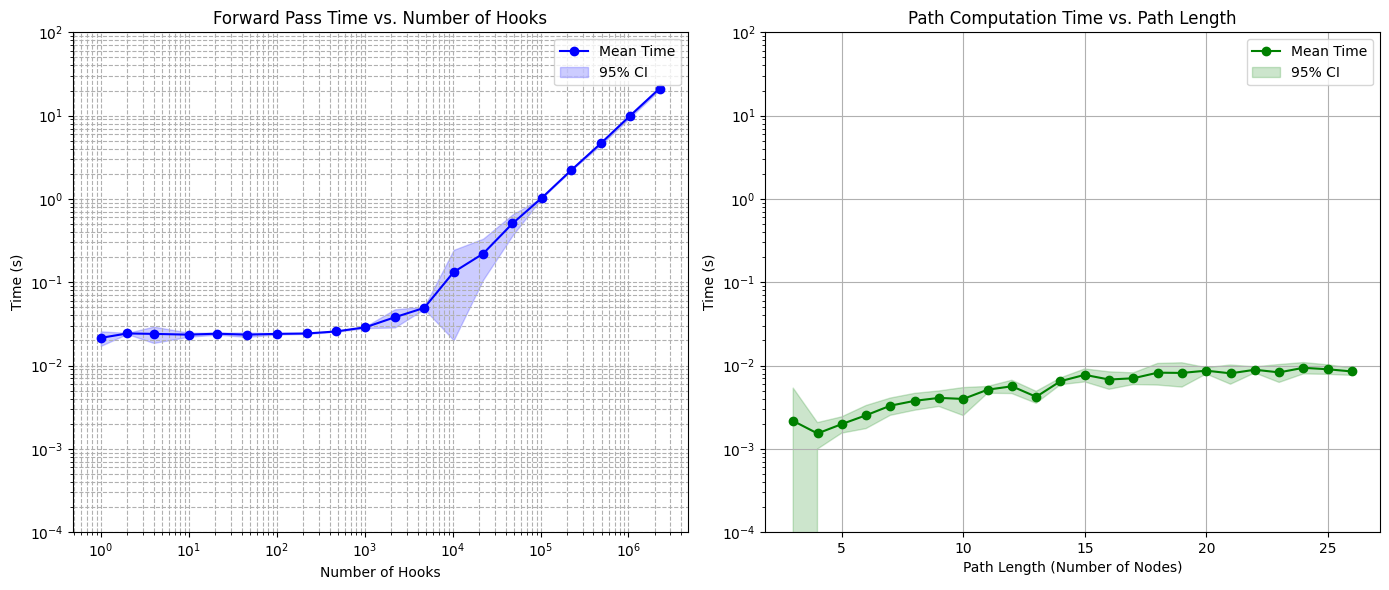

Hook Timing Results (Mean ± CI):
     1 hooks: 0.0215 ± 0.0043s
     2 hooks: 0.0243 ± 0.0004s
     4 hooks: 0.0240 ± 0.0053s
    10 hooks: 0.0235 ± 0.0013s
    21 hooks: 0.0241 ± 0.0007s
    46 hooks: 0.0235 ± 0.0014s
   101 hooks: 0.0240 ± 0.0004s
   219 hooks: 0.0242 ± 0.0003s
   473 hooks: 0.0256 ± 0.0002s
  1021 hooks: 0.0288 ± 0.0007s
  2206 hooks: 0.0380 ± 0.0093s
  4765 hooks: 0.0492 ± 0.0016s
  10292 hooks: 0.1324 ± 0.1123s
  22226 hooks: 0.2199 ± 0.1131s
  48001 hooks: 0.5072 ± 0.1429s
  103664 hooks: 1.0318 ± 0.0039s
  223874 hooks: 2.2181 ± 0.0076s
  483482 hooks: 4.6286 ± 0.1949s
  1044132 hooks: 9.9721 ± 0.4566s
  2254920 hooks: 21.1498 ± 0.7892s

Path Computation Timing Results (Mean ± CI):
  Path '0' (length 3): 0.0022 ± 0.0032s
  Path '1' (length 4): 0.0015 ± 0.0005s
  Path '2' (length 5): 0.0020 ± 0.0004s
  Path '3' (length 6): 0.0025 ± 0.0008s
  Path '4' (length 7): 0.0033 ± 0.0008s
  Path '5' (length 8): 0.0038 ± 0.0009s
  Path '6' (length 9): 0.0041 ± 0.0009s
  Pat

In [5]:
# Visualization

plt.figure(figsize=(14, 6))

# Plotting the results for hooks
ax1 = plt.subplot(1, 2, 1)
ax1.plot(hook_counts, hook_times_mean, marker='o', color='blue', label='Mean Time')
ax1.fill_between(hook_counts, hook_times_mean - hook_ci, hook_times_mean + hook_ci, color='blue', alpha=0.2, label=f'{int(CONFIDENCE_LEVEL*100)}% CI')
ax1.set_title('Forward Pass Time vs. Number of Hooks')
ax1.set_xlabel('Number of Hooks')
ax1.set_ylabel('Time (s)')
ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.set_ylim([1e-4, 1e2])
ax1.grid(True, which="both", ls="--")
ax1.legend()

# Plotting the results for paths
ax2 = plt.subplot(1, 2, 2)
path_len_values = [len(paths[k]) for k in path_lengths]
ax2.plot(path_len_values, path_times_mean, marker='o', color='green', label='Mean Time')
ax2.fill_between(path_len_values, path_times_mean - path_ci, path_times_mean + path_ci, color='green', alpha=0.2, label=f'{int(CONFIDENCE_LEVEL*100)}% CI')
ax2.set_title('Path Computation Time vs. Path Length')
ax2.set_xlabel('Path Length (Number of Nodes)')
ax2.set_ylabel('Time (s)')
ax2.set_yscale('log')
ax2.set_ylim([1e-4, 1e2])
ax2.grid(True)
ax2.legend()

plt.tight_layout()
plt.show()

# Part 4: Print raw data
print("Hook Timing Results (Mean ± CI):")
for count, mean_t, ci in zip(hook_counts, hook_times_mean, hook_ci):
    print(f"  {count:4d} hooks: {mean_t:.4f} ± {ci:.4f}s")

print("\nPath Computation Timing Results (Mean ± CI):")
for path_key, mean_t, ci in zip(path_lengths, path_times_mean, path_ci):
    print(f"  Path '{path_key}' (length {len(paths[path_key])}): {mean_t:.4f} ± {ci:.4f}s")

<Figure size 1200x700 with 0 Axes>

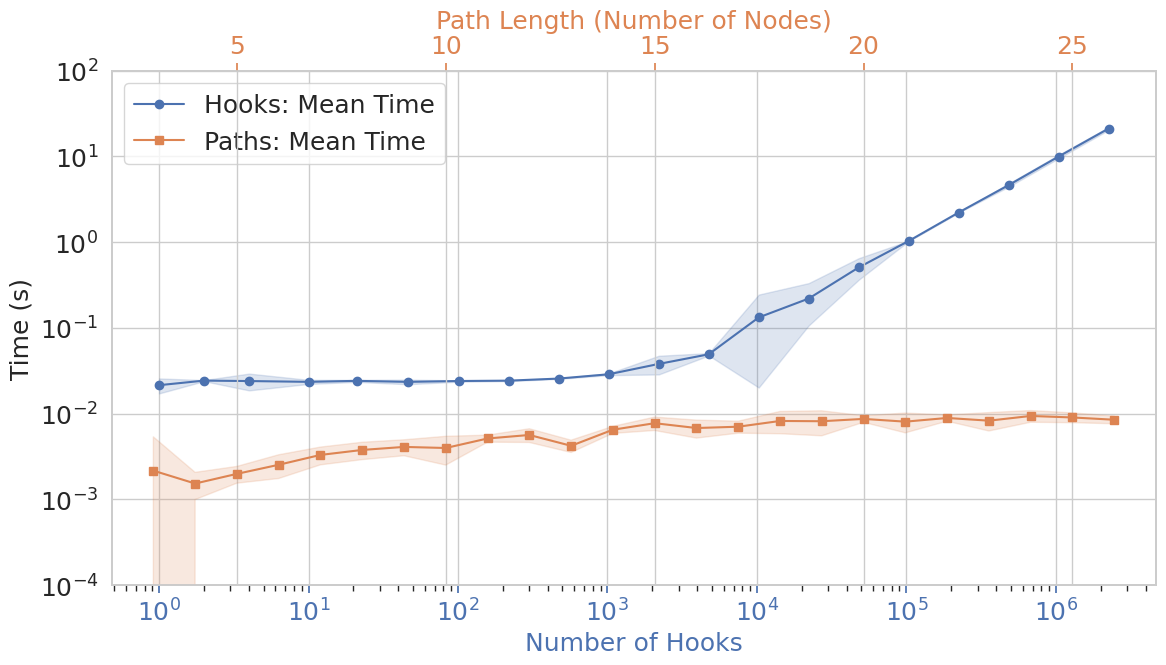

In [6]:
# Set a nice style and color palette with larger font sizes
sns.set(style="whitegrid", palette="muted", font_scale=1.5)
plt.figure(figsize=(12, 7))

fig, ax1 = plt.subplots(figsize=(12, 7))

color1 = sns.color_palette("deep")[0]
color2 = sns.color_palette("deep")[1]

# Plot hook timings
ln1 = ax1.plot(hook_counts, hook_times_mean, marker='o', color=color1, label='Hooks: Mean Time')
ax1.fill_between(hook_counts, hook_times_mean - hook_ci, hook_times_mean + hook_ci, color=color1, alpha=0.18)
ax1.set_xlabel('Number of Hooks', color=color1, fontsize=18)
ax1.set_ylabel('Time (s)', fontsize=18)
ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.tick_params(axis='x', colors=color1, labelsize=18)
ax1.tick_params(axis='y', labelsize=18)
ax1.set_ylim([1e-4, 1e2])

# Create a second x-axis for path length with custom limits
ax2 = ax1.twiny()
ln2 = ax2.plot(path_len_values, path_times_mean, marker='s', color=color2, label='Paths: Mean Time')
ax2.fill_between(path_len_values, path_times_mean - path_ci, path_times_mean + path_ci, color=color2, alpha=0.18)
ax2.set_xlabel('Path Length (Number of Nodes)', color=color2, fontsize=18)
ax2.tick_params(axis='x', colors=color2, labelsize=18)
ax2.set_xscale('linear')
ax2.set_xlim([len(paths[0])-1, len(paths[-1])+1])

# Legends
lns = ln1 + ln2
labels = [l.get_label() for l in lns]
ax1.legend(lns, labels, loc='upper left', frameon=True, fancybox=True, framealpha=0.8, fontsize=18)

# Titles and layout
# plt.title('Computation Time vs. Number of Hooks and Path Length', fontsize=20, pad=20)
fig.tight_layout()
plt.show()
